# Notebook 2 — Approche semi-supervisée

## Objectif du notebook

Ce notebook met en œuvre une approche semi-supervisée à partir des embeddings extraits précédemment.

L’objectif est de construire des weak labels à partir d’un clustering appris sur les données d’entraînement, puis de comparer un modèle supervisé classique à une approche semi-supervisée.

## 1. Chargement des données et rappel du contexte

In [1]:
import numpy as np
import pandas as pd

# Chargement des artefacts produits par le notebook 1
features = np.load("../data/features.npy")
true_labels = np.load("../data/true_labels.npy", allow_pickle=True)
image_paths = np.load("../data/image_paths.npy", allow_pickle=True)

# Alias conservé pour cohérence avec certaines cellules du notebook
labels = true_labels.copy()

# Reconstruction des index utiles
all_indices = np.arange(len(true_labels))
labeled_indices = np.where(true_labels != "unlabeled")[0]
unlabeled_idx = np.where(true_labels == "unlabeled")[0]

print("features shape :", features.shape)
print("Nombre total d'images :", len(image_paths))
print("Nombre d'images labellisées :", len(labeled_indices))
print("Nombre d'images non labellisées :", len(unlabeled_idx))

print("\nRépartition labels réels :")
for lab, count in zip(*np.unique(true_labels[labeled_indices], return_counts=True)):
    print(f"  {lab}: {count}")

features shape : (1506, 2048)
Nombre total d'images : 1506
Nombre d'images labellisées : 100
Nombre d'images non labellisées : 1406

Répartition labels réels :
  cancer: 50
  normal: 50


## 2. Protocole semi-supervisé
La phase précédente a permis d’explorer la structure des embeddings et de justifier le choix de KMeans avec K=2.

Pour rendre l’évaluation plus rigoureuse, on applique désormais le protocole suivant :

1. les 100 données labellisées sont séparées en un sous-ensemble d’entraînement et un sous-ensemble de test ;
2. le clustering final est appris sur les données disponibles pour l’apprentissage (labellisées d’entraînement + non labellisées) ;
3. le mapping cluster → label est construit uniquement à partir des données labellisées d’entraînement ;
4. les labels faibles sont générés pour les données non labellisées ;
5. on compare ensuite :
   - un modèle supervisé pur, entraîné uniquement sur les données labellisées d’entraînement ;
   - un modèle semi-supervisé, entraîné sur les données labellisées d’entraînement et les données non labellisées munies de labels faibles ;
6. l’évaluation finale est faite sur le sous-ensemble de test labellisé, jamais utilisé pour construire le mapping.

In [2]:
from sklearn.model_selection import train_test_split

# Split stratifié des données labellisées
train_idx, test_idx = train_test_split(
    labeled_indices,
    test_size=0.50,
    random_state=42,
    stratify=true_labels[labeled_indices]
)

print("Train labellisé :", len(train_idx))
print("Test labellisé  :", len(test_idx))

print("\nRépartition train :")
for lab, count in zip(*np.unique(true_labels[train_idx], return_counts=True)):
    print(f"  {lab}: {count}")

print("\nRépartition test :")
for lab, count in zip(*np.unique(true_labels[test_idx], return_counts=True)):
    print(f"  {lab}: {count}")

Train labellisé : 50
Test labellisé  : 50

Répartition train :
  cancer: 25
  normal: 25

Répartition test :
  cancer: 25
  normal: 25


## 3. Apprentissage du clustering final

Le clustering final est appris sur les données disponibles pour l’apprentissage : données labellisées d’entraînement et données non labellisées.

Le sous-ensemble de test labellisé reste totalement exclu de cette étape afin d’éviter toute fuite d’information.

In [3]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Données utilisées pour apprendre le clustering final :
# - données labellisées d'entraînement
# - données non labellisées
clustering_fit_idx = np.sort(np.concatenate([train_idx, unlabeled_idx]))

X_cluster_fit = features[clustering_fit_idx]

# PCA finale
pca_final = PCA(n_components=50)
X_cluster_fit_pca = pca_final.fit_transform(X_cluster_fit)

# KMeans final
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_final.fit(X_cluster_fit_pca)

# Projection de toutes les données dans l'espace PCA final
features_pca_final = pca_final.transform(features)

# Attribution d'un cluster à toutes les données
cluster_labels_final = kmeans_final.predict(features_pca_final)

print("Shape features_pca_final :", features_pca_final.shape)
print("Clusters finaux :", np.unique(cluster_labels_final))

Shape features_pca_final : (1506, 50)
Clusters finaux : [0 1]


## 4. Construction du mapping cluster → label

Chaque cluster est associé à un label à partir des seules données labellisées d’entraînement, selon la classe majoritaire observée dans le cluster.

In [4]:
import pandas as pd
from collections import Counter

def build_cluster_label_mapping(cluster_labels, true_labels, labeled_indices):
    mapping = {}
    rows = []

    labeled_set = set(labeled_indices.tolist())

    for cluster in np.unique(cluster_labels):
        cluster_idx = np.where(cluster_labels == cluster)[0]
        labeled_in_cluster = [i for i in cluster_idx if i in labeled_set]

        if len(labeled_in_cluster) == 0:
            mapping[cluster] = "unknown"
            rows.append({
                "cluster": int(cluster),
                "n_total_cluster": int(len(cluster_idx)),
                "n_labeled_in_cluster": 0,
                "n_cancer": 0,
                "n_normal": 0,
                "majority_label": "unknown",
                "majority_ratio": np.nan
            })
            continue

        labels_in_cluster = true_labels[labeled_in_cluster]
        counts = Counter(labels_in_cluster)

        n_cancer = counts.get("cancer", 0)
        n_normal = counts.get("normal", 0)

        majority_label, majority_count = counts.most_common(1)[0]
        majority_ratio = majority_count / len(labeled_in_cluster)

        mapping[cluster] = majority_label

        rows.append({
            "cluster": int(cluster),
            "n_total_cluster": int(len(cluster_idx)),
            "n_labeled_in_cluster": int(len(labeled_in_cluster)),
            "n_cancer": int(n_cancer),
            "n_normal": int(n_normal),
            "majority_label": majority_label,
            "majority_ratio": float(majority_ratio)
        })

    summary_df = pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)
    return mapping, summary_df


def predict_from_clusters(cluster_labels, mapping):
    return np.array([mapping.get(cluster, "unknown") for cluster in cluster_labels], dtype=object)

In [5]:
mapping, cluster_summary = build_cluster_label_mapping(
    cluster_labels_final,
    true_labels,
    train_idx
)

print("Mapping cluster -> label :")
print(mapping)

print("\nComposition des clusters :")
display(cluster_summary)

Mapping cluster -> label :
{np.int32(0): 'normal', np.int32(1): 'cancer'}

Composition des clusters :


,cluster,n_total_cluster,n_labeled_in_cluster,n_cancer,n_normal,majority_label,majority_ratio
0,0,675,32,8,24,normal,0.750000
1,1,831,18,17,1,cancer,0.944444


In [6]:
weak_labels = predict_from_clusters(cluster_labels_final, mapping)

confidence_map = dict(zip(cluster_summary["cluster"], cluster_summary["majority_ratio"]))
cluster_confidence = np.array([confidence_map.get(c, np.nan) for c in cluster_labels_final])

weak_labels_df = pd.DataFrame({
    "image_path": image_paths,
    "cluster": cluster_labels_final,
    "predicted_label_from_cluster": weak_labels,
    "cluster_confidence": cluster_confidence,
    "is_labeled": np.isin(np.arange(len(image_paths)), labeled_indices),
    "is_train_labeled": np.isin(np.arange(len(image_paths)), train_idx),
    "is_test_labeled": np.isin(np.arange(len(image_paths)), test_idx),
    "is_unlabeled": np.isin(np.arange(len(image_paths)), unlabeled_idx),
    "true_label": labels
})

display(weak_labels_df.head())

,image_path,cluster,predicted_label_from_cluster,cluster_confidence,is_labeled,is_train_labeled,is_test_labeled,is_unlabeled,true_label
0,../data/avec_labels/cancer/05340cd4-3bb2-459d-...,1,cancer,0.944444,True,False,True,False,cancer
1,../data/avec_labels/cancer/0c6f3641-60d9-4a76-...,0,normal,0.750000,True,False,True,False,cancer
2,../data/avec_labels/cancer/0f718241-8f63-4b55-...,0,normal,0.750000,True,False,True,False,cancer
3,../data/avec_labels/cancer/11a7a426-4806-401e-...,0,normal,0.750000,True,True,False,False,cancer
4,../data/avec_labels/cancer/1c043dbb-4623-4769-...,1,cancer,0.944444,True,True,False,False,cancer


## 5. Interprétation du weak labeling

Le mapping cluster → label est construit uniquement à partir des données labellisées d’entraînement.

Chaque donnée non labellisée reçoit ensuite un label faible correspondant au label majoritaire de son cluster.

Le champ `cluster_confidence` correspond à la proportion du label majoritaire parmi les données labellisées d’entraînement présentes dans le cluster. Il ne s’agit pas d’une probabilité calibrée, mais d’un indicateur simple de fiabilité du weak labeling.

## 6. Baseline supervisée
Un premier modèle supervisé est entraîné uniquement sur les données labellisées d’entraînement.

Cette baseline fournit un point de comparaison avant l’introduction des weak labels générés à partir du clustering.

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    recall_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

def plot_confusion_matrix(y_true, y_pred, title="Matrice de confusion"):
    labels_order = ["cancer", "normal"]
    cm = confusion_matrix(y_true, y_pred, labels=labels_order)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels_order,
        yticklabels=labels_order
    )
    plt.xlabel("Prédiction")
    plt.ylabel("Vérité terrain")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def build_logreg_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ])

def evaluate_model(name, model, X_test, y_test, threshold=0.5, show_proba_preview=True):
    classes = list(model.named_steps["clf"].classes_)
    cancer_idx = classes.index("cancer")

    y_proba = model.predict_proba(X_test)[:, cancer_idx]
    y_pred = np.where(y_proba >= threshold, "cancer", "normal")

    plot_confusion_matrix(y_test, y_pred, title=f"{name} (seuil={threshold})")

    recall_cancer = recall_score(y_test, y_pred, pos_label="cancer")

    print(f"\n=== {name} ===")
    print(f"Seuil utilisé pour la classe 'cancer' : {threshold:.2f}")

    print("\nClassification report :")
    print(classification_report(y_test, y_pred))

    print(f"Recall (cancer) : {recall_cancer:.2f}")
    print(f"Probabilité moyenne prédite (cancer) : {y_proba.mean():.2f}")
    print(f"Probabilité min/max (cancer) : {y_proba.min():.2f} / {y_proba.max():.2f}")

    if show_proba_preview:
        proba_preview = pd.DataFrame({
            "y_true": y_test,
            "proba_cancer": np.round(y_proba, 4),
            "prediction": y_pred
        }).reset_index(drop=True)

        print("\nAperçu des probabilités prédites :")
        display(proba_preview.head(10))

    metrics = {
        "model": name,
        "threshold": threshold,
        "recall_cancer": recall_cancer,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted")
    }

    return metrics, y_proba, y_pred

def show_most_uncertain_cases(y_test, y_proba, top_n=10):
    df_uncertain = pd.DataFrame({
        "y_true": y_test,
        "proba_cancer": y_proba
    }).reset_index(drop=True)

    # 1 = très incertain, 0 = très certain
    df_uncertain["uncertainty"] = 1 - (2 * np.abs(df_uncertain["proba_cancer"] - 0.5))

    df_uncertain = df_uncertain.sort_values("uncertainty", ascending=False).head(top_n)

    print(f"Top {top_n} cas les plus incertains :")
    display(df_uncertain)

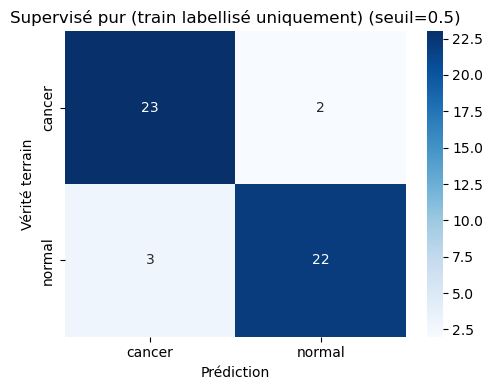


=== Supervisé pur (train labellisé uniquement) ===
Seuil utilisé pour la classe 'cancer' : 0.50

Classification report :
              precision    recall  f1-score   support

      cancer       0.88      0.92      0.90        25
      normal       0.92      0.88      0.90        25

    accuracy                           0.90        50
   macro avg       0.90      0.90      0.90        50
weighted avg       0.90      0.90      0.90        50

Recall (cancer) : 0.92
Probabilité moyenne prédite (cancer) : 0.52
Probabilité min/max (cancer) : 0.00 / 1.00

Aperçu des probabilités prédites :


,y_true,proba_cancer,prediction
0,normal,0.0766,normal
1,cancer,0.0589,normal
2,cancer,1.0000,cancer
3,normal,0.0046,normal
4,cancer,1.0000,cancer
5,cancer,0.0739,normal
6,cancer,0.9901,cancer
7,cancer,1.0000,cancer
8,cancer,1.0000,cancer
9,normal,0.9894,cancer


In [8]:
# Jeux de données
X_train_sup = features[train_idx]
y_train_sup = true_labels[train_idx]

X_test = features[test_idx]
y_test = true_labels[test_idx]

# Modèle supervisé pur
baseline_model = build_logreg_pipeline()
baseline_model.fit(X_train_sup, y_train_sup)

baseline_metrics, baseline_proba, baseline_pred = evaluate_model(
    "Supervisé pur (train labellisé uniquement)",
    baseline_model,
    X_test,
    y_test,
    threshold=0.5
)

## 7. Entraînement semi-supervisé sans filtrage

Dans un premier temps, toutes les données non labellisées reçoivent un weak label à partir du clustering et sont intégrées à l’entraînement avec une pondération réduite.

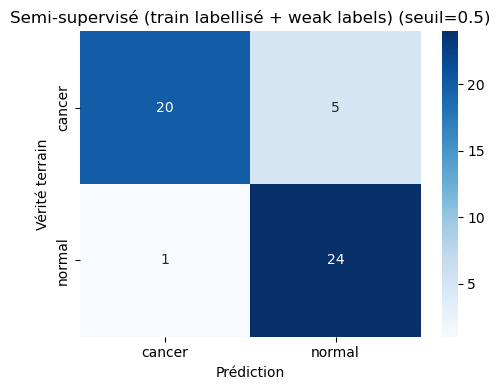


=== Semi-supervisé (train labellisé + weak labels) ===
Seuil utilisé pour la classe 'cancer' : 0.50

Classification report :
              precision    recall  f1-score   support

      cancer       0.95      0.80      0.87        25
      normal       0.83      0.96      0.89        25

    accuracy                           0.88        50
   macro avg       0.89      0.88      0.88        50
weighted avg       0.89      0.88      0.88        50

Recall (cancer) : 0.80
Probabilité moyenne prédite (cancer) : 0.42
Probabilité min/max (cancer) : 0.00 / 1.00

Aperçu des probabilités prédites :


,y_true,proba_cancer,prediction
0,normal,0.0000,normal
1,cancer,0.0001,normal
2,cancer,0.9998,cancer
3,normal,0.0000,normal
4,cancer,1.0000,cancer
5,cancer,0.0023,normal
6,cancer,0.9999,cancer
7,cancer,0.7784,cancer
8,cancer,1.0000,cancer
9,normal,0.0001,normal



Nombre d'échantillons faibles utilisés : 1406


In [9]:
# Construction du jeu d'entraînement semi-supervisé (sans filtrage)
X_train_semi_unfiltered = np.vstack([
    features[train_idx],
    features[unlabeled_idx]
])

y_train_semi_unfiltered = np.concatenate([
    true_labels[train_idx],
    weak_labels[unlabeled_idx]
])

# Pondération plus faible pour les labels faibles
sample_weights_unfiltered = np.concatenate([
    np.ones(len(train_idx)),
    np.full(len(unlabeled_idx), 0.5)
])

semi_model_unfiltered = build_logreg_pipeline()
semi_model_unfiltered.fit(
    X_train_semi_unfiltered,
    y_train_semi_unfiltered,
    clf__sample_weight=sample_weights_unfiltered
)

semi_metrics_unfiltered, semi_proba_unfiltered, semi_pred_unfiltered = evaluate_model(
    "Semi-supervisé (train labellisé + weak labels)",
    semi_model_unfiltered,
    X_test,
    y_test,
    threshold=0.5
)

print(f"\nNombre d'échantillons faibles utilisés : {len(unlabeled_idx)}")

## 8. Filtrage des weak labels

Les labels faibles générés automatiquement peuvent être bruités.

Un filtrage par niveau de confiance est donc appliqué afin de ne conserver que les weak labels les plus fiables avant l’entraînement semi-supervisé.

In [10]:
# Filtrage des weak labels peu fiables
confidence_threshold = 0.8

filtered_unlabeled_mask = (
    np.isin(np.arange(len(image_paths)), unlabeled_idx)
    & (weak_labels != "unknown")
    & (cluster_confidence >= confidence_threshold)
)

filtered_unlabeled_idx = np.where(filtered_unlabeled_mask)[0]

print("Nombre d'échantillons faibles avant filtrage :", np.sum(
    np.isin(np.arange(len(image_paths)), unlabeled_idx) & (weak_labels != "unknown")
))
print("Nombre d'échantillons faibles après filtrage :", len(filtered_unlabeled_idx))

Nombre d'échantillons faibles avant filtrage : 1406
Nombre d'échantillons faibles après filtrage : 792


## 9. Entraînement du modèle semi-supervisé

Le modèle semi-supervisé est entraîné sur les données labellisées d’entraînement, complétées par les données non labellisées munies de weak labels filtrés.

Une pondération plus faible est appliquée aux weak labels afin de limiter l’impact d’éventuelles erreurs de pseudo-annotation.

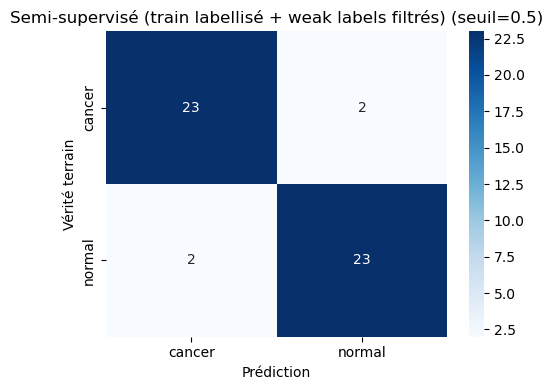


=== Semi-supervisé (train labellisé + weak labels filtrés) ===
Seuil utilisé pour la classe 'cancer' : 0.50

Classification report :
              precision    recall  f1-score   support

      cancer       0.92      0.92      0.92        25
      normal       0.92      0.92      0.92        25

    accuracy                           0.92        50
   macro avg       0.92      0.92      0.92        50
weighted avg       0.92      0.92      0.92        50

Recall (cancer) : 0.92
Probabilité moyenne prédite (cancer) : 0.51
Probabilité min/max (cancer) : 0.00 / 1.00

Aperçu des probabilités prédites :


,y_true,proba_cancer,prediction
0,normal,0.0278,normal
1,cancer,0.2375,normal
2,cancer,0.9985,cancer
3,normal,0.0027,normal
4,cancer,1.0000,cancer
5,cancer,0.0570,normal
6,cancer,0.9995,cancer
7,cancer,0.9999,cancer
8,cancer,1.0000,cancer
9,normal,0.7588,cancer



Nombre d'échantillons faibles utilisés : 792


In [11]:
X_train_semi_filtered = np.vstack([
    features[train_idx],
    features[filtered_unlabeled_idx]
])

y_train_semi_filtered = np.concatenate([
    true_labels[train_idx],
    weak_labels[filtered_unlabeled_idx]
])

# Pondération plus faible pour les labels faibles filtrés
sample_weights_filtered = np.concatenate([
    np.ones(len(train_idx)),
    np.full(len(filtered_unlabeled_idx), 0.3)
])

semi_model_filtered = build_logreg_pipeline()
semi_model_filtered.fit(
    X_train_semi_filtered,
    y_train_semi_filtered,
    clf__sample_weight=sample_weights_filtered
)

semi_metrics_filtered, semi_proba_filtered, semi_pred_filtered = evaluate_model(
    "Semi-supervisé (train labellisé + weak labels filtrés)",
    semi_model_filtered,
    X_test,
    y_test,
    threshold=0.5
)

print(f"\nNombre d'échantillons faibles utilisés : {len(filtered_unlabeled_idx)}")

## 10. Comparaison des performances

Les résultats du modèle supervisé pur et du modèle semi-supervisé sont comparés sur le même jeu de test labellisé.

In [12]:
comparison_df = pd.DataFrame([
    baseline_metrics,
    semi_metrics_unfiltered,
    semi_metrics_filtered
])[["model", "threshold", "recall_cancer", "accuracy", "balanced_accuracy", "f1_macro", "f1_weighted"]]

display(comparison_df)

,model,threshold,recall_cancer,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,Supervisé pur (train labellisé uniquement),0.5,0.92,0.90,0.90,0.899960,0.899960
1,Semi-supervisé (train labellisé + weak labels),0.5,0.80,0.88,0.88,0.879227,0.879227
2,Semi-supervisé (train labellisé + weak labels ...,0.5,0.92,0.92,0.92,0.920000,0.920000


## 11. Ouverture vers le passage à l’échelle

L’utilisation de `predict_proba` permet d’obtenir un score de confiance pour chaque prédiction.

En production, cette probabilité peut être utilisée pour :
- ajuster le seuil de décision selon les priorités métier ;
- maximiser le recall en contexte de dépistage ;
- identifier les cas incertains à faire relire par un expert.

Cette logique ouvre la voie à une stratégie d’active learning, dans laquelle seuls les cas les plus ambigus sont envoyés en annotation humaine, afin de maîtriser les coûts à grande échelle.

In [13]:
show_most_uncertain_cases(y_test, semi_proba_filtered, top_n=10)

Top 10 cas les plus incertains :


,y_true,proba_cancer,uncertainty
37,normal,0.428406,0.856812
9,normal,0.758793,0.482415
1,cancer,0.237471,0.474941
22,cancer,0.868767,0.262467
46,normal,0.057712,0.115424
5,cancer,0.056957,0.113914
0,normal,0.027800,0.055600
33,normal,0.010724,0.021447
41,normal,0.010718,0.021436
44,normal,0.003101,0.006203


L’intérêt principal de predict_proba n’est pas sur les données labellisées, mais sur les données non labellisées. On peut identifier les cas les plus ambigus et les envoyer en priorité à annotation humaine, ce qui permet d’optimiser le coût d’annotation à grande échelle.

In [14]:
def show_most_uncertain_cases(y_proba, image_paths=None, indices=None, top_n=10):
    df = pd.DataFrame({
        "proba_cancer": y_proba
    }).reset_index(drop=True)

    df["distance_to_0.5"] = np.abs(df["proba_cancer"] - 0.5)

    if image_paths is not None and indices is not None:
        df["image_path"] = image_paths[indices]

    # TRI : les plus proches de 0.5 en premier
    df = df.sort_values("distance_to_0.5", ascending=True).head(top_n)

    print(f"Top {top_n} cas les plus incertains (proches de 0.5) :")
    display(df)

In [15]:
# Prédiction sur les données non labellisées
classes = list(semi_model_filtered.named_steps["clf"].classes_)
cancer_idx = classes.index("cancer")

y_proba_unlabeled = semi_model_filtered.predict_proba(features[unlabeled_idx])[:, cancer_idx]

show_most_uncertain_cases(
    y_proba_unlabeled,
    image_paths=image_paths,
    indices=unlabeled_idx,
    top_n=10
)

Top 10 cas les plus incertains (proches de 0.5) :


,proba_cancer,distance_to_0.5,image_path
86,0.501461,0.001461,../data/sans_label/0e50ebae-64c8-4178-bca4-de3...
1061,0.507002,0.007002,../data/sans_label/c3b3d8bc-8c66-41fb-9cee-1e4...
833,0.507002,0.007002,../data/sans_label/9b2736c3-5b1b-45fd-ba9b-b1b...
372,0.490686,0.009314,../data/sans_label/438833fd-6e2c-4a08-915e-dd9...
1333,0.509376,0.009376,../data/sans_label/f4047893-67fd-4a03-b0b6-dd7...
861,0.509763,0.009763,../data/sans_label/a2662c2f-32e2-490d-aece-f0a...
426,0.484703,0.015297,../data/sans_label/4f957598-f192-4dca-863d-f85...
1353,0.484666,0.015334,../data/sans_label/f5e0d8e5-d8be-4308-9584-808...
788,0.483134,0.016866,../data/sans_label/92100fd8-bdbd-49a3-bf65-3f6...
481,0.480657,0.019343,../data/sans_label/5a3b10ea-d871-4565-ab46-604...


## 12. Sauvegarde des artefacts

Les weak labels, le mapping cluster → label et les indices du split sont sauvegardés pour assurer la traçabilité de l’expérience.

In [16]:
import json

# Export des weak labels
weak_labels_df.to_csv("../data/weak_labels_clustering.csv", index=False)

# Export du mapping cluster -> label
mapping_to_save = {int(k): str(v) for k, v in mapping.items()}
with open("../data/cluster_mapping_k2.json", "w", encoding="utf-8") as f:
    json.dump(mapping_to_save, f, ensure_ascii=False, indent=2)

# Export des indices train/test pour la traçabilité
np.savez(
    "../data/semi_supervised_split.npz",
    train_idx=train_idx,
    test_idx=test_idx,
    filtered_unlabeled_idx=filtered_unlabeled_idx
)

print("Artefacts sauvegardés :")
print("- ../data/weak_labels_clustering.csv")
print("- ../data/cluster_mapping_k2.json")
print("- ../data/semi_supervised_split.npz")

Artefacts sauvegardés :
- ../data/weak_labels_clustering.csv
- ../data/cluster_mapping_k2.json
- ../data/semi_supervised_split.npz


## Conclusion finale

L’approche semi-supervisée mise en œuvre dans ce notebook permet d’exploiter les données non labellisées à partir d’un weak labeling construit sur les clusters.

Le protocole reste rigoureux :
- le jeu de test est totalement séparé ;
- le mapping cluster → label est appris uniquement sur les données labellisées d’entraînement ;
- les weak labels sont filtrés avant d’être utilisés.

La comparaison entre baseline supervisée et approche semi-supervisée permet ainsi d’évaluer concrètement l’intérêt d’exploiter les données non annotées lorsque les labels experts sont limités.